In [1]:
from classifier import *
from wav_to_embedding import *
from baseline_features import *
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore") # suppress all warnings

In [2]:
# Create Mel and Mfcc objects
mel_extractor = Mel(n_mel_bands=80, n_fft=1024, sampling_rate=16000, frame_length_ms=25,
                    frame_shift_ms=5, window='hamming', eps=1e-10, fmin=0, fmax=None, htk=False)
mfcc_extractor = Mfcc(n_mel_bands=80, n_fft=1024, sampling_rate=16000, frame_length_ms=25,
                      frame_shift_ms=5, n_coeff=13, eps=1e-10)

# Spectogram

In [3]:
wav_files = get_wav_files("data")

features = []
for file_path, label in tqdm.tqdm(wav_files, desc="Processing WAV files"):
    # Obtain the feature for the current WAV file
    waveform = mel_extractor.load_wav(file_path)
    feature_array = mel_extractor.spec(waveform)
    feature = np.mean(feature_array, axis=1)
    features.append((file_path, label, feature))

# Convert the data list to a DataFrame
features_df = pd.DataFrame(features, columns=['Soundtrack', 'Label', 'feature'])

X = np.array(list(features_df['feature']))
y = features_df['Label']

# Create a DataFrame to store results
results_spec_df = pd.DataFrame({'Fold': [], 'Fold_Accuracy': []})
confusion_matrices_spec = []

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5)

# Store cross-validation results
for fold_num, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train SVM classifier
    svm_classifier = SVC(kernel='linear')  # Linear kernel works well for high-dimensional data
    svm_classifier.fit(X_train, y_train)

    # Calculate accuracy
    accuracy = svm_classifier.score(X_test, y_test)

    # Print accuracy for each fold
    # print(f"Accuracy for Layer {layer_num}, Fold {fold_num}: {accuracy}")

    # Store fold results
    fold_results_spec_df = pd.DataFrame({
        'Fold': [fold_num],
        'Fold_Accuracy': [accuracy]
    }, index=[0])
    results_spec_df = pd.concat([results_spec_df, fold_results_spec_df], ignore_index=True)
    
    # Generate confusion matrix
    y_pred = svm_classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices_spec.append((fold_num, cm))

Processing WAV files: 100%|██████████████████| 762/762 [00:05<00:00, 142.68it/s]


In [4]:
results_spec_df

,Fold,Fold_Accuracy
0,0.0,0.771242
1,1.0,0.803922
2,2.0,0.809211
3,3.0,0.835526
4,4.0,0.776316


In [5]:
results_spec_df['Fold_Accuracy'].mean()

0.7992432060543516

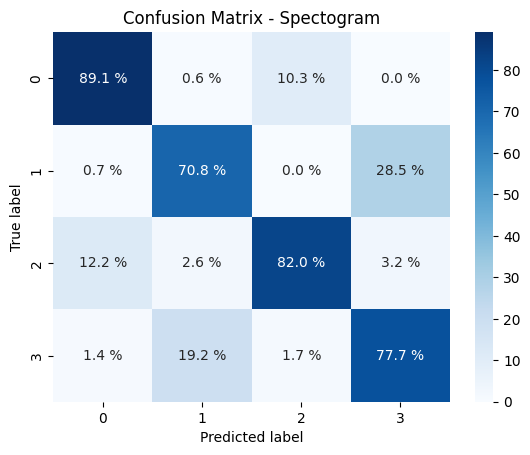

In [6]:
combined_cm = None
for fold, cm in confusion_matrices_spec:
    if combined_cm is None:
        combined_cm = cm
    else:
        combined_cm += cm

if combined_cm is not None:
    # Calculate percentages
    cm_sum = np.sum(combined_cm, axis=1, keepdims=True)
    combined_cm_percentage = np.round(100 * combined_cm / cm_sum, 2)

    plt.figure()
    plot = sns.heatmap(combined_cm_percentage, annot=True, fmt='.1f', cmap='Blues')
    for t in plot.texts: t.set_text(t.get_text() + " %")
    plt.title(f'Confusion Matrix - Spectogram')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

# Mel-spectogram

In [7]:
wav_files = get_wav_files("data")

features = []
for file_path, label in tqdm.tqdm(wav_files, desc="Processing WAV files"):
    # Obtain the feature for the current WAV file
    waveform = mel_extractor.load_wav(file_path)
    feature_array = mel_extractor.melspectrogram(waveform)
    feature = np.mean(feature_array, axis=1)
    features.append((file_path, label, feature))

# Convert the data list to a DataFrame
features_df = pd.DataFrame(features, columns=['Soundtrack', 'Label', 'feature'])

X = np.array(list(features_df['feature']))
y = features_df['Label']

# Create a DataFrame to store results
results_mspec_df = pd.DataFrame({'Fold': [], 'Fold_Accuracy': []})
confusion_matrices_mspec = []

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5)

# Store cross-validation results
for fold_num, (train_index, test_index) in tqdm.tqdm(enumerate(skf.split(X, y)), "K-Fold CV"):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train SVM classifier
    svm_classifier = SVC(kernel='linear')  # Linear kernel works well for high-dimensional data
    svm_classifier.fit(X_train, y_train)

    # Calculate accuracy
    accuracy = svm_classifier.score(X_test, y_test)

    # Print accuracy for each fold
    # print(f"Accuracy for Layer {layer_num}, Fold {fold_num}: {accuracy}")

    # Store fold results
    fold_results_mspec_df = pd.DataFrame({
        'Fold': [fold_num],
        'Fold_Accuracy': [accuracy]
    }, index=[0])
    results_mspec_df = pd.concat([results_mspec_df, fold_results_mspec_df], ignore_index=True)
    
    # Generate confusion matrix
    y_pred = svm_classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices_mspec.append((fold_num, cm))

Processing WAV files: 100%|██████████████████| 762/762 [00:05<00:00, 144.78it/s]
K-Fold CV: 5it [00:00, 24.16it/s]


In [8]:
results_mspec_df

,Fold,Fold_Accuracy
0,0.0,0.784314
1,1.0,0.764706
2,2.0,0.822368
3,3.0,0.815789
4,4.0,0.763158


In [9]:
results_mspec_df['Fold_Accuracy'].mean()

0.7900670794633642

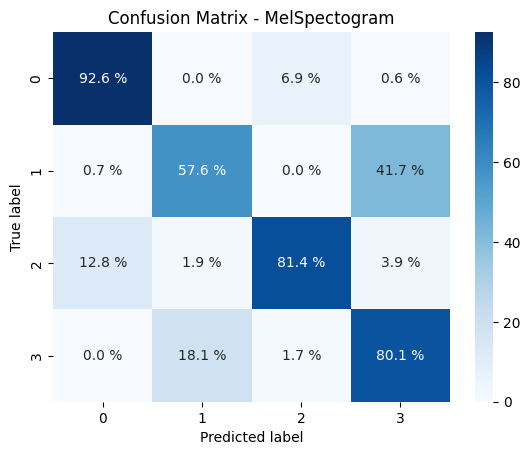

In [10]:
combined_cm = None
for fold, cm in confusion_matrices_mspec:
    if combined_cm is None:
        combined_cm = cm
    else:
        combined_cm += cm

if combined_cm is not None:
    # Calculate percentages
    cm_sum = np.sum(combined_cm, axis=1, keepdims=True)
    combined_cm_percentage = np.round(100 * combined_cm / cm_sum, 2)

    plt.figure()
    plot = sns.heatmap(combined_cm_percentage, annot=True, fmt='.1f', cmap='Blues')
    for t in plot.texts: t.set_text(t.get_text() + " %")
    plt.title(f'Confusion Matrix - MelSpectogram')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

# MFCCs

In [11]:
wav_files = get_wav_files("data")

features = []
for file_path, label in tqdm.tqdm(wav_files, desc="Processing WAV files"):
    # Obtain the feature for the current WAV file
    waveform = mel_extractor.load_wav(file_path)
    feature_array = mfcc_extractor.DeltaMfcc(waveform)
    feature = np.mean(feature_array, axis=1)
    features.append((file_path, label, feature))

# Convert the data list to a DataFrame
features_df = pd.DataFrame(features, columns=['Soundtrack', 'Label', 'feature'])

X = np.array(list(features_df['feature']))
y = features_df['Label']

# Create a DataFrame to store results
results_mfccs_df = pd.DataFrame({'Fold': [], 'Fold_Accuracy': []})
confusion_matrices_mfccs = []

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5)

# Store cross-validation results
for fold_num, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train SVM classifier
    svm_classifier = SVC(kernel='linear')  # Linear kernel works well for high-dimensional data
    svm_classifier.fit(X_train, y_train)

    # Calculate accuracy
    accuracy = svm_classifier.score(X_test, y_test)

    # Print accuracy for each fold
    # print(f"Accuracy for Layer {layer_num}, Fold {fold_num}: {accuracy}")

    # Store fold results
    fold_results_mfccs_df = pd.DataFrame({
        'Fold': [fold_num],
        'Fold_Accuracy': [accuracy]
    }, index=[0])
    results_mfccs_df = pd.concat([results_mfccs_df, fold_results_mfccs_df], ignore_index=True)
    
    # Generate confusion matrix
    y_pred = svm_classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices_mfccs.append((fold_num, cm))

Processing WAV files: 100%|██████████████████| 762/762 [00:06<00:00, 110.18it/s]


In [12]:
results_mfccs_df

,Fold,Fold_Accuracy
0,0.0,0.712418
1,1.0,0.686275
2,2.0,0.789474
3,3.0,0.763158
4,4.0,0.710526


In [13]:
results_mfccs_df['Fold_Accuracy'].mean()

0.7323701410388717

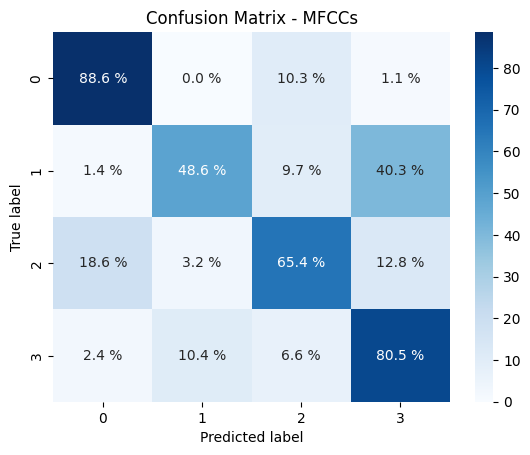

In [14]:
combined_cm = None
for fold, cm in confusion_matrices_mfccs:
    if combined_cm is None:
        combined_cm = cm
    else:
        combined_cm += cm

if combined_cm is not None:
    # Calculate percentages
    cm_sum = np.sum(combined_cm, axis=1, keepdims=True)
    combined_cm_percentage = np.round(100 * combined_cm / cm_sum, 2)

    plt.figure()
    plot = sns.heatmap(combined_cm_percentage, annot=True, fmt='.1f', cmap='Blues')
    for t in plot.texts: t.set_text(t.get_text() + " %")
    plt.title(f'Confusion Matrix - MFCCs')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

## poc/archive

In [15]:
wav_files = get_wav_files("data")
file_path = wav_files[0][0]

In [16]:
embedding_tensors = wav_to_embedding(file_path, "hubert")

In [17]:
np.mean(embedding_tensors[0].detach().numpy(), axis=1).shape

(1, 1024)

In [18]:
np.mean(embedding_tensors[0].detach().numpy(), axis=1)[0].shape

(1024,)

In [19]:
embedding_tensors[0].detach().numpy().flatten().shape

(60416,)

In [20]:
# Create Mel and Mfcc objects
mel_extractor = Mel(n_mel_bands=80, n_fft=1024, sampling_rate=16000, frame_length_ms=25,
                    frame_shift_ms=5, window='hamming', eps=1e-10, fmin=0, fmax=None, htk=False)
mfcc_extractor = Mfcc(n_mel_bands=80, n_fft=1024, sampling_rate=16000, frame_length_ms=25,
                      frame_shift_ms=5, n_coeff=13, eps=1e-10)

# Load audio file
waveform = mel_extractor.load_wav(file_path)

# Compute Mel-spectrogram and MFCCs
spec = mel_extractor.spec(waveform)
mel_spec = mel_extractor.melspectrogram(waveform)
mfcc = mfcc_extractor.DeltaMfcc(waveform)

In [21]:
spec.shape

(513, 240)

In [22]:
mel_spec.shape

(80, 240)

In [23]:
mfcc.shape

(39, 240)